<a href="https://colab.research.google.com/github/FRJackson/MBS-first_vs1/blob/main/coxmodel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os, pandas as pd, numpy as np, csv



df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/5398/middle1_2024_withid.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipython-input-1032189525.py:7: DtypeWarning: Columns (27) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/5398/middle1_2024_withid.csv')


In [ ]:
df=df.drop(columns=['Unnamed: 0','y_next','payment_history'])

In [ ]:
df.columns

Index(['period', 'loan_identifier', 'first_payment_date', 'maturity_date',
       'original_loan_term', 'original_interest_rate', 'original_upb',
       'upb_at_issuance', 'number_of_units', 'number_of_borrowers',
       'credit_score', 'original_loan_to_value_ltv',
       'original_combined_loan_to_value_cltv',
       'original_debt_to_income_dti_ratio',
       'mortgage_insurance_percentage_mi_percent', 'loan_age',
       'remaining_months_to_legal_maturity',
       'adjusted_remaining_months_to_maturity_rmm',
       'current_loan_delinquency_status', 'current_interest_rate',
       'current_actual_upb', 'current_interest_bearing_upb',
       'estimated_loan_to_value_ltv_quarterly',
       'updated_credit_score_1_quarterly', 'number_of_modifications',
       'modification_first_payment_date', 'modification_debt_to_income_ratio',
       'total_capitalized_amount', 'property_valuation_method',
       'is_delinquent_next_month', 'unemp_rate_state', 'cpi_us',
       'unemp_rate_state_ma3

# 数据结构调整

In [ ]:
import pandas as pd

# 假设你的原始数据叫 df
# 必须至少包含以下三列:
# 'loan_id', 'period', 'is_delinquent_next_month'

df = df.sort_values(["loan_identifier", "period"])

def keep_until_first_default(group):
    # 找到首次违约发生的位置
    default_rows = group.index[group["is_delinquent_next_month"] == 1]

    if len(default_rows) > 0:
        first_default_idx = default_rows[0]
        # 截断到首次违约这一行（包括这一行）
        group = group.loc[:first_default_idx]
        # event=1 在首次违约这行，其余为 0
        group["event"] = 0
        group.loc[first_default_idx, "event"] = 1
    else:
        # 没有违约 → 全部保留，最后一行 event=0（删失）
        group["event"] = 0
    return group

surv = df.groupby("loan_identifier", group_keys=False).apply(keep_until_first_default)


/tmp/ipython-input-627797388.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  surv = df.groupby("loan_identifier", group_keys=False).apply(keep_until_first_default)


In [ ]:
from sklearn.impute import SimpleImputer
import pandas as pd

surv = surv.copy()

# -------------------------------
# 1. 数值列缺失值填补（跳过全 NaN 列）
# -------------------------------
num_cols = surv.select_dtypes(include=["int64", "float64"]).columns

# 有至少一个非缺失值的数值列
valid_num_cols = [c for c in num_cols if surv[c].notna().any()]
# 全部是 NaN 的数值列
empty_num_cols = [c for c in num_cols if not surv[c].notna().any()]

print("数值列总数:", len(num_cols))
print("可插补的数值列:", len(valid_num_cols))
print("全 NaN 的数值列:", empty_num_cols)

if valid_num_cols:
    imputer_num = SimpleImputer(strategy="median")
    surv[valid_num_cols] = imputer_num.fit_transform(surv[valid_num_cols])

# 对于全 NaN 的数值列，可以选择：
# 方案1：直接删掉（一般没信息）
surv = surv.drop(columns=empty_num_cols)

# 如果你不想删，而是想填 0，可以换成：
# for c in empty_num_cols:
#     surv[c] = 0.0

# -------------------------------
# 2. 类别列缺失值填补（most_frequent）
# -------------------------------
# -------------------------------
# 2. 类别列缺失值填补（most_frequent）——安全版本
# -------------------------------
cat_cols = surv.select_dtypes(include=["object"]).columns

# 有至少一个非缺失值的类别列
valid_cat_cols = [c for c in cat_cols if surv[c].notna().any()]
# 全 NaN 的类别列
empty_cat_cols = [c for c in cat_cols if not surv[c].notna().any()]

print("类别列总数:", len(cat_cols))
print("可插补的类别列:", len(valid_cat_cols))
print("全 NaN 的类别列:", empty_cat_cols)

if valid_cat_cols:
    imputer_cat = SimpleImputer(strategy="most_frequent")
    surv[valid_cat_cols] = imputer_cat.fit_transform(surv[valid_cat_cols])

# 对于全 NaN 的类别列，直接删掉（一般没信息）
surv = surv.drop(columns=empty_cat_cols)

# 如果你不想删，而是想保留，可以改成：
# for c in empty_cat_cols:
#     surv[c] = "UNKNOWN"



数值列总数: 81
可插补的数值列: 79
全 NaN 的数值列: ['modification_debt_to_income_ratio', 'total_capitalized_amount']
类别列总数: 5
可插补的类别列: 4
全 NaN 的类别列: ['modification_first_payment_date']


In [ ]:
surv["period"]=pd.to_datetime(surv["period"])

In [ ]:
surv.head()

,period,loan_identifier,first_payment_date,maturity_date,original_loan_term,original_interest_rate,original_upb,upb_at_issuance,number_of_units,number_of_borrowers,...,modification_type_U,interest_rate_step_indicator_N,borrower_assistance_plan_F,borrower_assistance_plan_R,borrower_assistance_plan_T,payment_deferral_flag_C,payment_deferral_flag_P,distressed_principal_balance_flag_N,distressed_principal_balance_flag_Y,event
0,2024-03-01,24DNA1000001,2023-02-01,2053-01-01,360.0,6.375,340000.0,336405.26,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
59003,2024-04-01,24DNA1000001,2023-02-01,2053-01-01,360.0,6.375,340000.0,336405.26,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
118006,2024-05-01,24DNA1000001,2023-02-01,2053-01-01,360.0,6.375,340000.0,336405.26,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
177009,2024-06-01,24DNA1000001,2023-02-01,2053-01-01,360.0,6.375,340000.0,336405.26,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
236012,2024-07-01,24DNA1000001,2023-02-01,2053-01-01,360.0,6.375,340000.0,336405.26,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
import pandas as pd



# 把 period 展开成年和月
surv["year"] = surv["period"].dt.year
surv["month"] = surv["period"].dt.month

# 把年月映射成一个“绝对月份编号”，例如 2020-01 -> 2020*12+1
surv["abs_month"] = surv["year"] * 12 + surv["month"]

# 以全局最小的 abs_month 为 0，后面依次 1,2,3...
min_abs_month = surv["abs_month"].min()
surv["t_start"] = surv["abs_month"] - min_abs_month
surv["t_stop"] = surv["t_start"] + 1



In [ ]:
surv.shape

(854461, 88)

In [ ]:
surv.loc[surv['is_delinquent_next_month']==1]

,period,loan_identifier,first_payment_date,maturity_date,original_loan_term,original_interest_rate,original_upb,upb_at_issuance,number_of_units,number_of_borrowers,...,payment_deferral_flag_C,payment_deferral_flag_P,distressed_principal_balance_flag_N,distressed_principal_balance_flag_Y,event,year,month,abs_month,t_start,t_stop
472059,2024-11-01,24DNA1000038,2023-02-01,2053-01-01,360.0,6.625,428000.0,423729.67,1.0,2.0,...,0.0,0.0,1.0,0.0,1.0,2024,11,24299,8,9
708072,2025-03-01,24DNA1000039,2023-03-01,2053-02-01,360.0,6.625,237000.0,234658.05,1.0,2.0,...,0.0,0.0,1.0,0.0,1.0,2025,3,24303,12,13
472066,2024-11-01,24DNA1000046,2023-02-01,2053-01-01,360.0,6.490,314000.0,311181.42,1.0,1.0,...,0.0,0.0,1.0,0.0,1.0,2024,11,24299,8,9
590076,2025-01-01,24DNA1000051,2023-01-01,2052-12-01,360.0,7.500,104000.0,103041.33,1.0,1.0,...,0.0,0.0,1.0,0.0,1.0,2025,1,24301,10,11
81,2024-03-01,24DNA1000092,2023-02-01,2053-01-01,360.0,7.500,154000.0,151961.44,1.0,2.0,...,0.0,0.0,1.0,0.0,1.0,2024,3,24291,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
353859,2024-08-01,24DNA1064650,2023-02-01,2053-01-01,360.0,6.990,120000.0,118883.71,1.0,1.0,...,0.0,0.0,1.0,0.0,1.0,2024,8,24296,5,6
766933,2025-03-01,24DNA1064708,2023-03-01,2053-02-01,360.0,7.490,92000.0,91296.29,1.0,1.0,...,0.0,0.0,1.0,0.0,1.0,2025,3,24303,12,13
825947,2025-04-01,24DNA1064725,2023-04-01,2053-03-01,360.0,6.000,219000.0,203000.00,1.0,1.0,...,0.0,0.0,1.0,0.0,1.0,2025,4,24304,13,14
176938,2024-05-01,24DNA1064751,2023-04-01,2053-03-01,360.0,6.375,166000.0,162786.34,1.0,1.0,...,0.0,0.0,1.0,0.0,1.0,2024,5,24293,2,3


In [ ]:
surv.head()

,period,loan_identifier,first_payment_date,maturity_date,original_loan_term,original_interest_rate,original_upb,upb_at_issuance,number_of_units,number_of_borrowers,...,payment_deferral_flag_C,payment_deferral_flag_P,distressed_principal_balance_flag_N,distressed_principal_balance_flag_Y,event,year,month,abs_month,t_start,t_stop
0,2024-03-01,24DNA1000001,2023-02-01,2053-01-01,360.0,6.375,340000.0,336405.26,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,2024,3,24291,0,1
59003,2024-04-01,24DNA1000001,2023-02-01,2053-01-01,360.0,6.375,340000.0,336405.26,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,2024,4,24292,1,2
118006,2024-05-01,24DNA1000001,2023-02-01,2053-01-01,360.0,6.375,340000.0,336405.26,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,2024,5,24293,2,3
177009,2024-06-01,24DNA1000001,2023-02-01,2053-01-01,360.0,6.375,340000.0,336405.26,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,2024,6,24294,3,4
236012,2024-07-01,24DNA1000001,2023-02-01,2053-01-01,360.0,6.375,340000.0,336405.26,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,2024,7,24295,4,5


## 去掉信息泄露列

In [ ]:
leak_cols = [

    # 直接给出未来违约结果
    "is_delinquent_next_month",

    # 季度更新的后验特征（包含未来信用信息）
    "estimated_loan_to_value_ltv_quarterly",
    "updated_credit_score_1_quarterly",

    # delinquency history —— 对 Cox 首违约模型是未来信息
    "has_dq_3m", "has_dq_6m", "has_dq_12m", "has_dq_24m",
    "has_dq_gt03_3m", "has_dq_gt03_6m", "has_dq_gt03_12m", "has_dq_gt03_24m",
    "has_dq_gt05_3m", "has_dq_gt05_6m", "has_dq_gt05_12m", "has_dq_gt05_24m",

    # 救助/恢复特征 —— 违约之后的状态信息
    "recovered_from_dq_12m",

    # 上个月 delinquency → 会泄漏首次违约前信息
    "prev_month_status",
    "prev_month_is_delinquent",
    'current_loan_delinquency_status'
]


In [ ]:
surv_use = surv.copy()   # 或者 surv，如果你是这个名字

ID_COL = "loan_identifier"
TIME_COL = "t_stop"
EVENT_COL = "event"

# 1. 明确一个「很保守的安全特征候选」列表
safe_feature_candidates = [

    # —— orig 静态贷款信息 ——
    "original_loan_term",
    "original_interest_rate",
    "original_upb",
    "upb_at_issuance",
    "number_of_units",
    "number_of_borrowers",
    "credit_score",
    "original_loan_to_value_ltv",
    "original_combined_loan_to_value_cltv",
    "original_debt_to_income_dti_ratio",
    "mortgage_insurance_percentage_mi_percent",

    # —— 时间相关但本质是「当前时间」 + 合同信息，不是表现 ——
    "loan_age",
    "remaining_months_to_legal_maturity",
    "adjusted_remaining_months_to_maturity_rmm",

    # （保不保 current_* 看你，先全部去掉表现类更稳：下面先不用 current_ 开头的）

    # —— 宏观变量 ——（当前时点/lag 宏观）
    "unemp_rate_state",
    "cpi_us",
    "unemp_rate_state_ma3",

    # —— 你之前工程出的长期均值特征（只要是按历史均值算的，也算静态）——
    "seller_name_avg_y",
    "servicer_name_avg_y",
    "property_state_avg_y",
    "est_monthly_payment_balanced",

    # —— one-hot 类别：放款时就知道的 ——
    "loan_purpose_C",
    "loan_purpose_N",
    "loan_purpose_P",
    "channel_B",
    "channel_C",
    "channel_R",
    "property_type_CO",
    "property_type_CP",
    "property_type_MH",
    "property_type_PU",
    "property_type_SF",
    "occupancy_status_I",
    "occupancy_status_P",
    "occupancy_status_S",
    "first_time_homebuyer_indicator_N",
    "first_time_homebuyer_indicator_Y",
    "special_eligibility_program_F",
    "special_eligibility_program_H",
    "modification_flag_P",
    "modification_flag_Y",
    #"delinquency_due_to_disaster_Y",  # 这个也建议先去掉，可以不放进来
    "modification_program_F",
    "modification_type_F",
    "modification_type_T",
    "modification_type_U",
    "interest_rate_step_indicator_N",
    "borrower_assistance_plan_F",
    "borrower_assistance_plan_R",
    "borrower_assistance_plan_T",
    "payment_deferral_flag_C",
    "payment_deferral_flag_P",
    "distressed_principal_balance_flag_N",
    "distressed_principal_balance_flag_Y",

    # —— 时间索引相关（如果你想）——
    "year",
    "month",
    "abs_month",
    "t_start",
]

# 2. 在 DataFrame 里取实际存在的列
safe_feature_cols = [c for c in safe_feature_candidates if c in surv_use.columns]

print("最终用于 Cox 的特征列：")
print(safe_feature_cols)

# 3. 之后所有训练都用 safe_feature_cols，而不是自动全选数值列
feature_cols = safe_feature_cols


最终用于 Cox 的特征列：
['original_loan_term', 'original_interest_rate', 'original_upb', 'upb_at_issuance', 'number_of_units', 'number_of_borrowers', 'credit_score', 'original_loan_to_value_ltv', 'original_combined_loan_to_value_cltv', 'original_debt_to_income_dti_ratio', 'mortgage_insurance_percentage_mi_percent', 'loan_age', 'remaining_months_to_legal_maturity', 'adjusted_remaining_months_to_maturity_rmm', 'unemp_rate_state', 'cpi_us', 'unemp_rate_state_ma3', 'seller_name_avg_y', 'servicer_name_avg_y', 'property_state_avg_y', 'est_monthly_payment_balanced', 'loan_purpose_C', 'loan_purpose_N', 'loan_purpose_P', 'channel_B', 'channel_C', 'channel_R', 'property_type_CO', 'property_type_CP', 'property_type_MH', 'property_type_PU', 'property_type_SF', 'occupancy_status_I', 'occupancy_status_P', 'occupancy_status_S', 'first_time_homebuyer_indicator_N', 'first_time_homebuyer_indicator_Y', 'special_eligibility_program_F', 'special_eligibility_program_H', 'modification_flag_P', 'modification_flag_Y', 

In [ ]:
# Survival 必需的列
surv_base_cols = [ID_COL, TIME_COL, EVENT_COL, "t_start"]

# 如果你还需要 period，就加上：
if "period" in surv_use.columns:
    surv_base_cols.append("period")

# 最终保留：survival 必需列 + 特征列
surv_clean = surv_use[surv_base_cols + feature_cols].copy()

print("surv_clean 形状：", surv_clean.shape)
print("列名：", surv_clean.columns.tolist())

surv_clean.shape

surv_clean 形状： (854461, 62)
列名： ['loan_identifier', 't_stop', 'event', 't_start', 'period', 'original_loan_term', 'original_interest_rate', 'original_upb', 'upb_at_issuance', 'number_of_units', 'number_of_borrowers', 'credit_score', 'original_loan_to_value_ltv', 'original_combined_loan_to_value_cltv', 'original_debt_to_income_dti_ratio', 'mortgage_insurance_percentage_mi_percent', 'loan_age', 'remaining_months_to_legal_maturity', 'adjusted_remaining_months_to_maturity_rmm', 'unemp_rate_state', 'cpi_us', 'unemp_rate_state_ma3', 'seller_name_avg_y', 'servicer_name_avg_y', 'property_state_avg_y', 'est_monthly_payment_balanced', 'loan_purpose_C', 'loan_purpose_N', 'loan_purpose_P', 'channel_B', 'channel_C', 'channel_R', 'property_type_CO', 'property_type_CP', 'property_type_MH', 'property_type_PU', 'property_type_SF', 'occupancy_status_I', 'occupancy_status_P', 'occupancy_status_S', 'first_time_homebuyer_indicator_N', 'first_time_homebuyer_indicator_Y', 'special_eligibility_program_F', 'sp

(854461, 62)

In [ ]:
surv_clean = surv.copy()

# 所有实际存在的「未来信息列」
actual_leaks = [c for c in leak_cols if c in surv_clean.columns]

print("将要删除的未来信息（leakage）列：")
print(actual_leaks)

# 删除这些列
surv_clean = surv_clean.drop(columns=actual_leaks)

print("\n删除后列总数：", len(surv_clean.columns))


将要删除的未来信息（leakage）列：
['is_delinquent_next_month', 'estimated_loan_to_value_ltv_quarterly', 'updated_credit_score_1_quarterly', 'has_dq_3m', 'has_dq_6m', 'has_dq_12m', 'has_dq_24m', 'has_dq_gt03_3m', 'has_dq_gt03_6m', 'has_dq_gt03_12m', 'has_dq_gt03_24m', 'has_dq_gt05_3m', 'has_dq_gt05_6m', 'has_dq_gt05_12m', 'has_dq_gt05_24m', 'recovered_from_dq_12m', 'prev_month_status', 'prev_month_is_delinquent', 'current_loan_delinquency_status']

删除后列总数： 69


# 数据集抽样

In [ ]:
ID_COL = "loan_identifier"

# 所有唯一贷款
all_ids = surv_clean[ID_COL].drop_duplicates()

# 按贷款抽一个子集，比如 5000 笔；如果贷款总数没那么多，可以改成 frac=0.3 这样
sample_ids = all_ids.sample(n=2000, random_state=0)  # 或者 sample(frac=0.2)

# 用这些贷款构造一个小数据集
surv_small = surv_clean[surv_clean[ID_COL].isin(sample_ids)].copy()


# 基础cox模型

In [ ]:
import numpy as np

def build_risk_sets(t_stop):
    """
    输入：t_stop 数组 (N,)
    输出：list of risk sets index arrays
    """
    order = np.argsort(t_stop)        # 按时间排序
    sorted_t = t_stop[order]

    risk_sets = []
    N = len(t_stop)

    # 对每个事件观察 j，找所有 k ≥ j
    for i in range(N):
        # 由于排过序，全满足 sorted_t[k] >= sorted_t[i] 的是后半段
        risk_set_idx = order[i:]
        risk_sets.append(risk_set_idx)

    return risk_sets, order


In [ ]:
import torch
import torch.nn as nn

class CoxModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        # 线性模型 η = Xβ
        self.beta = nn.Parameter(torch.zeros(input_dim))

    def forward(self, X):
        return X.matmul(self.beta)


In [ ]:
def cox_loss(eta, event, risk_sets):
    """
    eta: (N,)
    event: (N,) 0/1
    risk_sets: list of arrays
    """
    loglik = torch.tensor(0.0, device=eta.device)

    for j in range(len(eta)):
        if event[j] == 1:
            risk_idx = risk_sets[j]
            loglik = loglik + (eta[j] - torch.logsumexp(eta[risk_idx], dim=0))

    return -loglik   # 负号是因为我们要最小化


In [ ]:
def train_cox(X, t_stop, event, lr=1e-2, epoch=200):
    X_torch = torch.tensor(X, dtype=torch.float32)
    event_torch = torch.tensor(event, dtype=torch.float32)

    risk_sets, order = build_risk_sets(t_stop)

    # risk_sets 要是 torch 张量
    risk_sets = [torch.tensor(rs, dtype=torch.long) for rs in risk_sets]

    model = CoxModel(input_dim=X.shape[1])
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for ep in range(epoch):
        optimizer.zero_grad()
        eta = model(X_torch)
        loss = cox_loss(eta, event_torch, risk_sets)
        loss.backward()
        optimizer.step()

        if ep % 20 == 0:
            print(f"Epoch {ep:03d} | Loss = {loss.item():.4f}")

    return model


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
import torch

def concordance_index(t, event, risk):
    """
    Harrell's C-index（O(n^2)，样本太大时注意性能）
    t: numpy array (N,)
    event: numpy array (N,) 0/1
    risk: numpy array (N,) 风险分数（越大风险越高）
    """
    n = len(t)
    num = 0.0
    den = 0.0

    for i in range(n):
        for j in range(n):
            # 只比较：i 先于 j 发生事件，且 i 确实有事件
            if (t[i] < t[j]) and (event[i] == 1):
                den += 1
                if risk[i] > risk[j]:
                    num += 1
                elif risk[i] == risk[j]:
                    num += 0.5

    if den == 0:
        return np.nan
    return num / den


def prepare_survival_arrays(df, feature_cols, time_col, event_col):
    """
    把一个 survival DataFrame → (排序后的 df, X_scaled, t, e, scaler)
    会按照 time_col 升序排序
    """
    df_sorted = df.sort_values(time_col).reset_index(drop=True)

    X = df_sorted[feature_cols].values.astype(np.float32)
    t = df_sorted[time_col].values.astype(np.float32)
    e = df_sorted[event_col].values.astype(np.float32)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X).astype(np.float32)

    return df_sorted, X_scaled, t, e, scaler


def get_risk_score(model, X):
    """
    根据训练好的 Cox model 计算 risk score = exp(η)
    这里默认 model(X) 返回 η
    """
    with torch.no_grad():
        eta = model(torch.tensor(X, dtype=torch.float32))
    return np.exp(eta.numpy())


In [ ]:
import numpy as np

def cindex_on_sample(t, e, risk, max_n=5000, random_state=42):
    """
    为了省内存+时间，只在最多 max_n 个样本上算 C-index。
    t, e, risk 都是 numpy array。
    """
    n = len(t)
    if n > max_n:
        rng = np.random.default_rng(random_state)
        idx = rng.choice(n, size=max_n, replace=False)
        t = t[idx]
        e = e[idx]
        risk = risk[idx]
    return concordance_index(t, e, risk)


# 用完整数据集训练（会爆

In [ ]:
from pandas.api.types import is_numeric_dtype
# ====== 自动检测列名：把关键列写上，其余列全部自动当特征 ======

ID_COL = "loan_identifier"     # 你的贷款ID列名
TIME_COL = "t_stop"            # 连续整数时间
EVENT_COL = "event"            # 0/1 事件

# 自动获取所有列
all_cols = list(surv.columns)

# 自动推断特征列（排除 ID / 时间 / event / 非数值列）
feature_cols = [
    c for c in all_cols
    if c not in [ID_COL, TIME_COL, EVENT_COL]
    and is_numeric_dtype(surv[c])   # 只保留数值型
]

print("自动识别到的特征列：")
print(feature_cols)

# ====== 按贷款 ID 随机划分 train / test（避免数据泄漏） ======

loan_ids = surv[ID_COL].unique()
rng = np.random.default_rng(seed=42)
rng.shuffle(loan_ids)

n_total = len(loan_ids)
n_train = int(n_total * 0.8)

train_ids = set(loan_ids[:n_train])
test_ids = set(loan_ids[n_train:])

train_df = surv[surv[ID_COL].isin(train_ids)].copy()
test_df = surv[surv[ID_COL].isin(test_ids)].copy()

print(f"Train loans: {len(train_ids)}, Test loans: {len(test_ids)}")
print(f"Train rows:  {len(train_df)}")
print(f"Test rows:   {len(test_df)}")


自动识别到的特征列：
['original_loan_term', 'original_interest_rate', 'original_upb', 'upb_at_issuance', 'number_of_units', 'number_of_borrowers', 'credit_score', 'original_loan_to_value_ltv', 'original_combined_loan_to_value_cltv', 'original_debt_to_income_dti_ratio', 'mortgage_insurance_percentage_mi_percent', 'loan_age', 'remaining_months_to_legal_maturity', 'adjusted_remaining_months_to_maturity_rmm', 'current_loan_delinquency_status', 'current_interest_rate', 'current_actual_upb', 'current_interest_bearing_upb', 'estimated_loan_to_value_ltv_quarterly', 'updated_credit_score_1_quarterly', 'number_of_modifications', 'property_valuation_method', 'is_delinquent_next_month', 'unemp_rate_state', 'cpi_us', 'unemp_rate_state_ma3', 'seller_name_avg_y', 'servicer_name_avg_y', 'property_state_avg_y', 'est_monthly_payment_balanced', 'has_dq_3m', 'has_dq_6m', 'has_dq_12m', 'has_dq_24m', 'has_dq_gt03_3m', 'has_dq_gt03_6m', 'has_dq_gt03_12m', 'has_dq_gt03_24m', 'has_dq_gt05_3m', 'has_dq_gt05_6m', 'has_dq_

In [ ]:
# ===== 1. 先定一个 epoch 数，别交叉验证了 =====
LR = 1e-2
best_epoch = 100   # 你可以改成 50 / 80 / 150 等等

print(f"Use epochs = {best_epoch} (no cross-validation)")

# ===== 2. 在整个 train_df 上准备数据并训练 =====
train_df_s, X_train, t_train, e_train, scaler_full = prepare_survival_arrays(
    train_df, feature_cols, TIME_COL, EVENT_COL
)

print("Start training Cox model on full train...")
final_model = train_cox(
    X_train, t_train, e_train,
    lr=LR,
    epoch=best_epoch
)
print("Training finished.")

# ===== 3. 在 test_df 上做评估 =====
test_df_s = test_df.sort_values(TIME_COL).reset_index(drop=True)

X_test_raw = test_df_s[feature_cols].values.astype(np.float32)
X_test = scaler_full.transform(X_test_raw).astype(np.float32)
t_test = test_df_s[TIME_COL].values.astype(np.float32)
e_test = test_df_s[EVENT_COL].values.astype(np.float32)

risk_test = get_risk_score(final_model, X_test)

# 用抽样版 C-index，防止 O(N^2) 太夸张
c_test = cindex_on_sample(
    t_test,
    e_test,
    risk_test,
    max_n=10000,     # 最多抽 1w 个样本算 C-index
    random_state=0
)

print("\n===== Final result (no CV) =====")
print(f"Test C-index (sampled) = {c_test:.4f}")


Use epochs = 100 (no cross-validation)
Start training Cox model on full train...


KeyboardInterrupt: 

# 用小数据集尝试

In [ ]:
from pandas.api.types import is_numeric_dtype

# ============ 1. 用 surv_small，自动选特征 + train/test 划分 ============

ID_COL = "loan_identifier"   # 如果你叫 loan_id，就改这里
TIME_COL = "t_stop"
EVENT_COL = "event"

surv_small = surv_small.copy()

all_cols = list(surv_small.columns)

# 自动选数值特征列：排除 ID / 时间 / 事件，其余数值型都当特征
feature_cols = [
    c for c in all_cols
    if c not in [ID_COL, TIME_COL, EVENT_COL]
    and is_numeric_dtype(surv_small[c])
]

print("使用的特征列：", feature_cols)

# 按贷款 ID 划分 train/test
loan_ids = surv_small[ID_COL].unique()
rng = np.random.default_rng(seed=42)
rng.shuffle(loan_ids)

n_total = len(loan_ids)
n_train = int(n_total * 0.8)

train_ids = set(loan_ids[:n_train])
test_ids = set(loan_ids[n_train:])

train_df = surv_small[surv_small[ID_COL].isin(train_ids)].copy()
test_df  = surv_small[surv_small[ID_COL].isin(test_ids)].copy()

print(f"Train loans: {len(train_ids)}, Test loans: {len(test_ids)}")
print(f"Train rows:  {len(train_df)}, Test rows: {len(test_df)}")

使用的特征列： ['original_loan_term', 'original_interest_rate', 'original_upb', 'upb_at_issuance', 'number_of_units', 'number_of_borrowers', 'credit_score', 'original_loan_to_value_ltv', 'original_combined_loan_to_value_cltv', 'original_debt_to_income_dti_ratio', 'mortgage_insurance_percentage_mi_percent', 'loan_age', 'remaining_months_to_legal_maturity', 'adjusted_remaining_months_to_maturity_rmm', 'unemp_rate_state', 'cpi_us', 'unemp_rate_state_ma3', 'seller_name_avg_y', 'servicer_name_avg_y', 'property_state_avg_y', 'est_monthly_payment_balanced', 'loan_purpose_C', 'loan_purpose_N', 'loan_purpose_P', 'channel_B', 'channel_C', 'channel_R', 'property_type_CO', 'property_type_CP', 'property_type_MH', 'property_type_PU', 'property_type_SF', 'occupancy_status_I', 'occupancy_status_P', 'occupancy_status_S', 'first_time_homebuyer_indicator_N', 'first_time_homebuyer_indicator_Y', 'special_eligibility_program_F', 'special_eligibility_program_H', 'modification_flag_P', 'modification_flag_Y', 'modifi

In [ ]:
LR = 1e-2
best_epoch = 100    # 先定死，比如 100 轮，你可以之后再调

print(f"\nUse epochs = {best_epoch} (no cross-validation)")

# 准备训练集数组
train_df_s, X_train, t_train, e_train, scaler_full = prepare_survival_arrays(
    train_df, feature_cols, TIME_COL, EVENT_COL
)

print("Start training Cox model on full train...")
final_model = train_cox(
    X_train, t_train, e_train,
    lr=LR,
    epoch=best_epoch
)
print("Training finished.")


# ============ 3. 在 test 上评估 C-index ============

test_df_s = test_df.sort_values(TIME_COL).reset_index(drop=True)
X_test_raw = test_df_s[feature_cols].values.astype(np.float32)
X_test = scaler_full.transform(X_test_raw).astype(np.float32)
t_test = test_df_s[TIME_COL].values.astype(np.float32)
e_test = test_df_s[EVENT_COL].values.astype(np.float32)

risk_test = get_risk_score(final_model, X_test)

c_test = cindex_on_sample(
    t_test,
    e_test,
    risk_test,
    max_n=5000,      # 最多抽 5000 个样本算 C-index，避免 O(N^2) 太重
    random_state=0
)

print("\n===== Final result on surv_small (no CV) =====")
print(f"Test C-index (sampled) = {c_test:.4f}")


Use epochs = 100 (no cross-validation)
Start training Cox model on full train...
Epoch 000 | Loss = 749.5296
Epoch 020 | Loss = 590.3536
Epoch 040 | Loss = 493.9276
Epoch 060 | Loss = 413.2546
Epoch 080 | Loss = 338.8293
Training finished.

===== Final result on surv_small (no CV) =====
Test C-index (sampled) = 0.9594


In [ ]:
LR = 1e-2
best_epoch = 100    # 先定死，比如 100 轮，你可以之后再调

print(f"\nUse epochs = {best_epoch} (no cross-validation)")

# 准备训练集数组
train_df_s, X_train, t_train, e_train, scaler_full = prepare_survival_arrays(
    train_df, feature_cols, TIME_COL, EVENT_COL
)

print("Start training Cox model on full train...")
final_model = train_cox(
    X_train, t_train, e_train,
    lr=LR,
    epoch=best_epoch
)
print("Training finished.")

# ============ 3. 在 test 上评估 C-index ============

test_df_s = test_df.sort_values(TIME_COL).reset_index(drop=True)
X_test_raw = test_df_s[feature_cols].values.astype(np.float32)
X_test = scaler_full.transform(X_test_raw).astype(np.float32)
t_test = test_df_s[TIME_COL].values.astype(np.float32)
e_test = test_df_s[EVENT_COL].values.astype(np.float32)

risk_test = get_risk_score(final_model, X_test)

c_test = cindex_on_sample(
    t_test,
    e_test,
    risk_test,
    max_n=5000,      # 最多抽 5000 个样本算 C-index，避免 O(N^2) 太重
    random_state=0
)

print("\n===== Final result on surv_small (no CV) =====")
print(f"Test C-index (sampled) = {c_test:.4f}")



Use epochs = 100 (no cross-validation)
Start training Cox model on full train...
Epoch 000 | Loss = 749.5296
Epoch 020 | Loss = 590.3536
Epoch 040 | Loss = 493.9276
Epoch 060 | Loss = 413.2546
Epoch 080 | Loss = 338.8293
Training finished.

===== Final result on surv_small (no CV) =====
Test C-index (sampled) = 0.9594


In [ ]:
import numpy as np
import pandas as pd

# ---------- 1. 用训练集算 Breslow baseline H0(t) ----------
# 先算训练集上的线性预测器 η
risk_train = get_risk_score(final_model, X_train)

# 按时间升序排
order = np.argsort(t_train)
t_tr_sort = t_train[order]
e_tr_sort = e_train[order]
eta_tr_sort = risk_train[order]

exp_eta = np.exp(eta_tr_sort)

# risk set：因为按时间升序，R(t_j) = 所有 i>=j
risk_sum = np.cumsum(exp_eta[::-1])[::-1]    # ∑_{i∈R(t)} exp(η_i)

# 每个样本对应的增量 dΛ0(t)
delta_H = e_tr_sort / risk_sum              # d_t / ∑exp(η)

H0_raw = np.cumsum(delta_H)

# 合并到唯一时间点上
baseline_df = (
    pd.DataFrame({"t": t_tr_sort, "H0": H0_raw})
    .groupby("t", as_index=False)["H0"].max()
    .sort_values("t")
)

# 填满整数时间网格
t_min = int(t_train.min())
t_max = int(t_train.max())
full_t = np.arange(t_min, t_max + 1)

baseline_df = (
    baseline_df
    .set_index("t")
    .reindex(full_t, method="ffill")
    .reset_index()
    .rename(columns={"index": "t"})
)
baseline_df["H0"] = baseline_df["H0"].fillna(0.0)
baseline_df["S0"] = np.exp(-baseline_df["H0"])

print("baseline_df 预览：")
print(baseline_df.head())

H0 = baseline_df["H0"].values.astype(float)   # baseline 累积 hazard
t_grid = baseline_df["t"].values.astype(int)
T = len(H0)

# ---------- 2. 在 test 上算 S(t|x) 和 PD(t->t+1) ----------
eta_te = risk_test
alpha_te = np.exp(eta_te)                    # hazard ratio

# S(t|x) = exp(-H0(t) * exp(η(x)))
S_te = np.exp(-np.outer(alpha_te, H0))       # (n_test, T)
PD_te = S_te[:, :-1] - S_te[:, 1:]           # (n_test, T-1)

print("S_te shape:", S_te.shape)
print("PD_te shape:", PD_te.shape)


baseline_df 预览：
   t   H0   S0
0  1  0.0  1.0
1  2  0.0  1.0
2  3  0.0  1.0
3  4  0.0  1.0
4  5  0.0  1.0
S_te shape: (5823, 15)
PD_te shape: (5823, 14)


/tmp/ipython-input-2469566415.py:57: RuntimeWarning: overflow encountered in exp
  return np.exp(eta.numpy())
/tmp/ipython-input-2272082548.py:14: RuntimeWarning: overflow encountered in exp
  exp_eta = np.exp(eta_tr_sort)
/tmp/ipython-input-2272082548.py:55: RuntimeWarning: overflow encountered in exp
  alpha_te = np.exp(eta_te)                    # hazard ratio
/usr/local/lib/python3.12/dist-packages/numpy/_core/numeric.py:971: RuntimeWarning: invalid value encountered in multiply
  return multiply(a.ravel()[:, newaxis], b.ravel()[newaxis, :], out)


有效样本数: 5375
坏客比例: 0.0029767441860465114
AUC (next-interval PD) = 0.5254711699944019


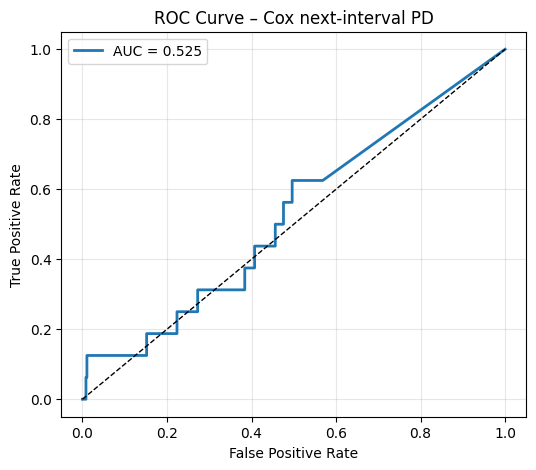

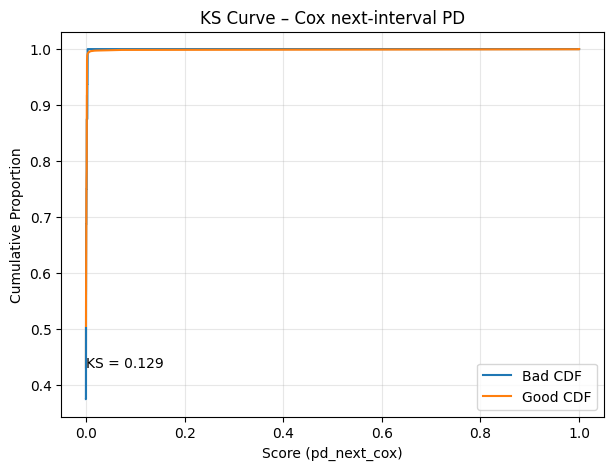

KS (Cox PD_next) = 0.12882534054860983


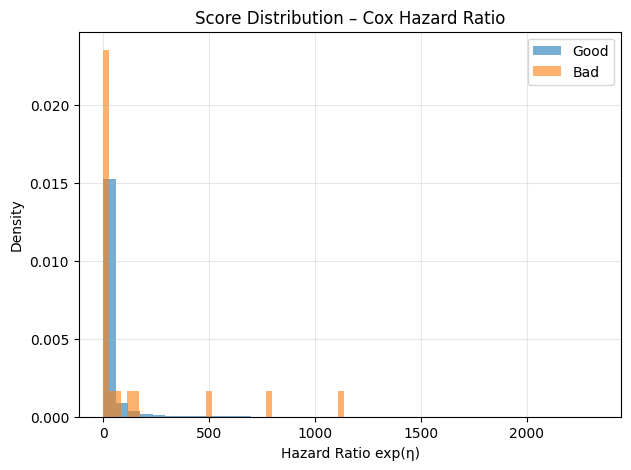

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 1. 取每一行对应的 next-interval PD
# ============================================================
t_test_int = t_test.astype(int)
e_test_int = e_test.astype(int)

row_idx = np.arange(len(t_test_int))
col_idx = t_test_int - 1
col_idx = np.clip(col_idx, 0, PD_te.shape[1]-1)

pd_next_cox = PD_te[row_idx, col_idx]

# 去掉 NaN / inf
mask = np.isfinite(pd_next_cox)
y_true = e_test_int[mask]
score  = pd_next_cox[mask]

print("有效样本数:", len(score))
print("坏客比例:", y_true.mean())

# ============================================================
# 2. ROC 曲线
# ============================================================
fpr, tpr, _ = roc_curve(y_true, score)
auc_val = roc_auc_score(y_true, score)

print("AUC (next-interval PD) =", auc_val)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc_val:.3f}")
plt.plot([0,1], [0,1], "k--", linewidth=1)
plt.title("ROC Curve – Cox next-interval PD")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# 3. KS 曲线（CDF）
# ============================================================
bad_scores  = score[y_true == 1]
good_scores = score[y_true == 0]

all_scores = np.sort(np.unique(score))

cdf_bad  = np.searchsorted(np.sort(bad_scores),  all_scores, side="right") / len(bad_scores)
cdf_good = np.searchsorted(np.sort(good_scores), all_scores, side="right") / len(good_scores)

ks_vals = np.abs(cdf_bad - cdf_good)
ks_max  = ks_vals.max()
ks_score = all_scores[ks_vals.argmax()]

plt.figure(figsize=(7,5))
plt.plot(all_scores, cdf_bad,  label="Bad CDF")
plt.plot(all_scores, cdf_good, label="Good CDF")
plt.vlines(ks_score, cdf_good[ks_vals.argmax()], cdf_bad[ks_vals.argmax()])
plt.text(
    ks_score,
    (cdf_bad[ks_vals.argmax()] + cdf_good[ks_vals.argmax()]) / 2,
    f"KS = {ks_max:.3f}",
    ha="left",
    va="center"
)
plt.title("KS Curve – Cox next-interval PD")
plt.xlabel("Score (pd_next_cox)")
plt.ylabel("Cumulative Proportion")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("KS (Cox PD_next) =", ks_max)

# ============================================================
# 4. Score Distribution
# ============================================================

# 自动推断合理的 x 轴范围（排除少量极端值）
# Cox risk score = exp(η)
risk_test = get_risk_score(final_model, X_test)

bad_scores  = risk_test[e_test == 1]
good_scores = risk_test[e_test == 0]

plt.figure(figsize=(7,5))
plt.hist(good_scores, bins=40, alpha=0.6, density=True, label="Good")
plt.hist(bad_scores,  bins=40, alpha=0.6, density=True, label="Bad")

plt.xlabel("Hazard Ratio exp(η)")
plt.ylabel("Density")
plt.title("Score Distribution – Cox Hazard Ratio")
plt.legend()
plt.grid(alpha=0.3)
plt.show()




In [ ]:
print("min/max:", score.min(), score.max())
print("quantiles:", np.quantile(score, [0, 0.5, 0.9, 0.99, 0.999]))


min/max: 0.0 1.0
quantiles: [0.00000000e+00 1.81731502e-05 1.55459005e-03 2.98226001e-03
 4.90700496e-01]


# 尝试算法1


In [ ]:
surv_small.columns

Index(['loan_identifier', 't_stop', 'event', 't_start', 'period',
       'original_loan_term', 'original_interest_rate', 'original_upb',
       'upb_at_issuance', 'number_of_units', 'number_of_borrowers',
       'credit_score', 'original_loan_to_value_ltv',
       'original_combined_loan_to_value_cltv',
       'original_debt_to_income_dti_ratio',
       'mortgage_insurance_percentage_mi_percent', 'loan_age',
       'remaining_months_to_legal_maturity',
       'adjusted_remaining_months_to_maturity_rmm', 'unemp_rate_state',
       'cpi_us', 'unemp_rate_state_ma3', 'seller_name_avg_y',
       'servicer_name_avg_y', 'property_state_avg_y',
       'est_monthly_payment_balanced', 'loan_purpose_C', 'loan_purpose_N',
       'loan_purpose_P', 'channel_B', 'channel_C', 'channel_R',
       'property_type_CO', 'property_type_CP', 'property_type_MH',
       'property_type_PU', 'property_type_SF', 'occupancy_status_I',
       'occupancy_status_P', 'occupancy_status_S',
       'first_time_homebuyer_

In [ ]:
def cox_log_partial_lik(eta, time, event):
    """
    数值稳定版 Breslow 部分似然：
    sum_{i: event_i=1} (eta_i - log sum_{j: t_j >= t_i} exp(eta_j))
    用 logcumsumexp 做 risk set 的 log 和。
    """
    # 按时间升序排序
    order = torch.argsort(time)
    t_sorted = time[order]
    e_sorted = event[order]
    eta_sorted = eta[order]

    # log ∑ exp(eta_j) over risk sets: 从后往前累加
    # 先从后往前做 logcumsumexp，再 flip 回来
    log_risk_sum = torch.logcumsumexp(eta_sorted.flip(0), dim=0).flip(0)

    mask = (e_sorted > 0)
    if mask.sum() == 0:
        return torch.tensor(0.0, device=eta.device)

    logL = torch.sum(eta_sorted[mask] - log_risk_sum[mask])
    return logL

def log_prior(model, sigma_beta=2.0, sigma_gamma=2.0, sigma_u=1.0):
    logp = 0.0

    # β 先验
    logp_beta = -0.5 * torch.sum((model.beta / sigma_beta) ** 2)
    # 加上常数项没必要（只是差个常数而已）

    logp = logp + logp_beta

    # γ 先验
    if model.gamma is not None:
        logp_gamma = -0.5 * torch.sum((model.gamma / sigma_gamma) ** 2)
        logp = logp + logp_gamma

    # u 先验（frailty）
    if model.u is not None:
        logp_u = -0.5 * torch.sum((model.u / sigma_u) ** 2)
        logp = logp + logp_u

    return logp


def neg_log_posterior(model, X, Zs, Zf, time, event,
                      sigma_beta=2.0, sigma_gamma=2.0, sigma_u=1.0):
    """
    返回负对数后验：- (logL + logPrior)，用于优化（越小越好）
    """
    eta = model(X, Zs, Zf)
    logL = cox_log_partial_lik(eta, time, event)
    logP = log_prior(model, sigma_beta, sigma_gamma, sigma_u)
    # 我们最大化 log posterior，相当于最小化 - (logL + logP)
    return -(logL + logP)


In [ ]:
import numpy as np

# 用 df = surv_small.sort_values("t_stop").reset_index(drop=True) 那个
df = df.copy()

ID_COL = "loan_identifier"
TIME_COL = "t_stop"
EVENT_COL = "event"

# 1) 按贷款 ID 拆分 80% / 20%
loan_ids = df[ID_COL].unique()
rng = np.random.default_rng(42)
rng.shuffle(loan_ids)

n_total = len(loan_ids)
n_train = int(n_total * 0.8)

train_ids = set(loan_ids[:n_train])
test_ids  = set(loan_ids[n_train:])

print(f"总贷款数 = {n_total},  train = {len(train_ids)}, test = {len(test_ids)}")

# 2) 构造布尔掩码（基于行）
mask_train = df[ID_COL].isin(train_ids).values
mask_test  = df[ID_COL].isin(test_ids).values

print("train 样本行数 =", mask_train.sum())
print("test 样本行数  =", mask_test.sum())

# 3) 在 numpy 设计矩阵上做拆分
X_lin_tr = X_lin[mask_train]
X_lin_te = X_lin[mask_test]

Zs_tr = Z_spline[mask_train]
Zs_te = Z_spline[mask_test]

Zf_tr = Z_frail[mask_train]
Zf_te = Z_frail[mask_test]

time_tr = y_time[mask_train]
time_te = y_time[mask_test]

event_tr = y_event[mask_train]
event_te = y_event[mask_test]

print("X_lin_tr shape:", X_lin_tr.shape, " X_lin_te shape:", X_lin_te.shape)
print("Zs_tr shape:", Zs_tr.shape, " Zs_te shape:", Zs_te.shape)
print("Zf_tr shape:", Zf_tr.shape, " Zf_te shape:", Zf_te.shape)


总贷款数 = 2000,  train = 1600, test = 400
train 样本行数 = 23280
test 样本行数  = 5811
X_lin_tr shape: (23280, 46)  X_lin_te shape: (5811, 46)
Zs_tr shape: (23280, 12)  Zs_te shape: (5811, 12)
Zf_tr shape: (23280, 8)  Zf_te shape: (5811, 8)


In [ ]:
import numpy as np

# ====== 1. 线性特征标准化：X_lin ======
X_mean = X_lin_tr.mean(axis=0, keepdims=True)
X_std  = X_lin_tr.std(axis=0, keepdims=True)
# 避免除 0
X_std[X_std < 1e-6] = 1.0

X_lin_tr_s = (X_lin_tr - X_mean) / X_std
X_lin_te_s = (X_lin_te - X_mean) / X_std

# ====== 2. spline 特征标准化：Zs ======
if Zs_tr.shape[1] > 0:
    Zs_mean = Zs_tr.mean(axis=0, keepdims=True)
    Zs_std  = Zs_tr.std(axis=0, keepdims=True)
    Zs_std[Zs_std < 1e-6] = 1.0

    Zs_tr_s = (Zs_tr - Zs_mean) / Zs_std
    Zs_te_s = (Zs_te - Zs_mean) / Zs_std
else:
    Zs_tr_s = Zs_tr
    Zs_te_s = Zs_te

# ====== 3. frailty 特征保持 0/1：Zf ======
Zf_tr_s = Zf_tr
Zf_te_s = Zf_te

print("X_lin_tr_s shape:", X_lin_tr_s.shape, " X_lin_te_s shape:", X_lin_te_s.shape)
print("Zs_tr_s shape:", Zs_tr_s.shape,     " Zs_te_s shape:", Zs_te_s.shape)
print("Zf_tr_s shape:", Zf_tr_s.shape,     " Zf_te_s shape:", Zf_te_s.shape)


X_lin_tr_s shape: (23280, 46)  X_lin_te_s shape: (5811, 46)
Zs_tr_s shape: (23280, 12)  Zs_te_s shape: (5811, 12)
Zf_tr_s shape: (23280, 8)  Zf_te_s shape: (5811, 8)


In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_tr_t = torch.from_numpy(X_lin_tr_s.astype(np.float32)).to(device)
Zs_tr_t = torch.from_numpy(Zs_tr_s.astype(np.float32)).to(device)
Zf_tr_t = torch.from_numpy(Zf_tr_s.astype(np.float32)).to(device)
time_tr_t = torch.from_numpy(time_tr.astype(np.float32)).to(device)
event_tr_t = torch.from_numpy(event_tr.astype(np.float32)).to(device)

X_te_t = torch.from_numpy(X_lin_te_s.astype(np.float32)).to(device)
Zs_te_t = torch.from_numpy(Zs_te_s.astype(np.float32)).to(device)
Zf_te_t = torch.from_numpy(Zf_te_s.astype(np.float32)).to(device)
time_te_t = torch.from_numpy(time_te.astype(np.float32)).to(device)
event_te_t = torch.from_numpy(event_te.astype(np.float32)).to(device)

n_tr, p_lin = X_tr_t.shape
_, k_s = Zs_tr_t.shape
_, k_f = Zf_tr_t.shape

print(f"train: n={n_tr}, p_lin={p_lin}, k_s={k_s}, k_f={k_f}")
print(f"test:  n={X_te_t.shape[0]}")


train: n=23280, p_lin=46, k_s=12, k_f=8
test:  n=5811


In [ ]:
import copy

model = BayesianCoxPL(p_lin, k_s, k_f).to(device)

# 更小一点的学习率
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

n_epochs = 300
best_loss = float("inf")
best_state = None

for epoch in range(n_epochs):
    optimizer.zero_grad()
    loss = neg_log_posterior(
        model,
        X_tr_t, Zs_tr_t, Zf_tr_t,
        time_tr_t, event_tr_t,
        sigma_beta=1.5,   # 比之前 2.0 略强一点的正则
        sigma_gamma=1.0,
        sigma_u=0.7
    )
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
    optimizer.step()

    cur_loss = loss.item()
    if cur_loss < best_loss:
        best_loss = cur_loss
        best_state = copy.deepcopy(model.state_dict())

    if epoch % 20 == 0 or epoch == n_epochs - 1:
        print(f"Epoch {epoch:03d} | -log posterior (train) = {cur_loss:.4f}")

print("训练结束，best -log posterior( train ) =", best_loss)

# 回滚到最佳 MAP 参数
if best_state is not None:
    model.load_state_dict(best_state)

print("beta 前 5 个参数：", model.beta[:5].detach().cpu().numpy())
if model.gamma is not None and k_s > 0:
    print("gamma 前 5 个参数：", model.gamma[:5].detach().cpu().numpy())
if model.u is not None and k_f > 0:
    print("u 全部参数：", model.u.detach().cpu().numpy())


Epoch 000 | -log posterior (train) = 727.1840
Epoch 020 | -log posterior (train) = 713.1385
Epoch 040 | -log posterior (train) = 700.2427
Epoch 060 | -log posterior (train) = 689.6381
Epoch 080 | -log posterior (train) = 680.1990
Epoch 100 | -log posterior (train) = 671.8022
Epoch 120 | -log posterior (train) = 664.3878
Epoch 140 | -log posterior (train) = 657.7372
Epoch 160 | -log posterior (train) = 651.7473
Epoch 180 | -log posterior (train) = 646.3162
Epoch 200 | -log posterior (train) = 641.3685
Epoch 220 | -log posterior (train) = 636.8493
Epoch 240 | -log posterior (train) = 632.7148
Epoch 260 | -log posterior (train) = 628.9282
Epoch 280 | -log posterior (train) = 625.4570
Epoch 299 | -log posterior (train) = 622.4247
训练结束，best -log posterior( train ) = 622.4246826171875
beta 前 5 个参数： [ 0.10287268 -0.02794513 -0.11631672 -0.10659389  0.15275665]
gamma 前 5 个参数： [-0.08840057  0.15737642  0.15897565 -0.16954212 -0.15452424]
u 全部参数： [ 0.18563002 -0.08621316 -0.02030312 -0.16246669 

In [ ]:
with torch.no_grad():
    eta_te = model(X_te_t, Zs_te_t, Zf_te_t)
    risk_te = eta_te.detach().cpu().numpy()

cindex_test = cindex_on_sample(
    time_te,
    event_te,
    risk_te,
    max_n=5000,
    random_state=0
)

print(f"Final Test C-index (Bayesian Cox MAP, scaled) = {cindex_test:.4f}")


Final Test C-index (Bayesian Cox MAP, scaled) = 0.9285


In [ ]:
print("min t_stop:", df["t_stop"].min())
print("max t_stop:", df["t_stop"].max())


min t_stop: 1
max t_stop: 15


# 算法2 3

In [ ]:
import numpy as np
import pandas as pd
import torch

# 用训练集计算线性预测器 η_hat
with torch.no_grad():
    eta_tr = model(X_tr_t, Zs_tr_t, Zf_tr_t).detach().cpu().numpy().reshape(-1)

t_tr = time_tr.astype(float)     # shape (n_train,)
e_tr = event_tr.astype(float)    # 0/1

# 1. 按时间排序
order = np.argsort(t_tr)
t_sorted = t_tr[order]
e_sorted = e_tr[order]
eta_sorted = eta_tr[order]

# 2. 计算风险集的 ∑ exp(η)
exp_eta = np.exp(eta_sorted)
# 反向累加（从最大时间往前走），得到每个样本对应的 risk set 和
risk_sum = np.cumsum(exp_eta[::-1])[::-1]   # shape (n_train,)

# 3. Breslow baseline：每个事件贡献 e_i / risk_sum_i
#    这里 e_sorted 是 0/1，所以非事件时贡献为 0
increment = e_sorted / risk_sum            # shape (n_train,)
H0_sorted = np.cumsum(increment)           # 累积得到 H0(t_i) 对应的值

# 4. 压缩到“按时间分组”的 baseline table
baseline_df = (
    pd.DataFrame({
        "t": t_sorted,
        "H0": H0_sorted,
    })
    .groupby("t", as_index=False)
    .agg({"H0": "max"})      # 某个 t 有多行，就取该 t 下最大的 H0（最后一次）
    .sort_values("t")
)

# 5. 确保时间网格是完整的 1..15（没有事件的月份，H0 持平）
t_min = int(df[TIME_COL].min())
t_max = int(df[TIME_COL].max())
full_t = np.arange(t_min, t_max + 1)

baseline_df = baseline_df.set_index("t").reindex(full_t, method="ffill")
baseline_df.index.name = "t"
baseline_df = baseline_df.reset_index()

# 对最早时间之前如果有 NaN，用 0 / 1 填掉
baseline_df["H0"] = baseline_df["H0"].fillna(0.0)

# 6. 计算 baseline survival S0(t) 和每月 baseline hazard 增量 h0(t)
baseline_df["S0"] = np.exp(-baseline_df["H0"])
baseline_df["h0"] = baseline_df["H0"].diff().fillna(baseline_df["H0"])

print("Baseline hazard / survival 表：")
print(baseline_df)


Baseline hazard / survival 表：
     t        H0        S0        h0
0    1  0.000247  0.999753  0.000247
1    2  0.000366  0.999634  0.000119
2    3  0.000639  0.999361  0.000272
3    4  0.000886  0.999115  0.000247
4    5  0.001156  0.998844  0.000271
5    6  0.001510  0.998491  0.000354
6    7  0.002941  0.997063  0.001431
7    8  0.003387  0.996619  0.000446
8    9  0.004953  0.995059  0.001567
9   10  0.006599  0.993423  0.001645
10  11  0.008035  0.991997  0.001436
11  12  0.009987  0.990063  0.001952
12  13  0.015014  0.985098  0.005027
13  14  0.023383  0.976888  0.008369
14  15  0.026526  0.973823  0.003143


In [ ]:
# 1. test 集的 η_hat
with torch.no_grad():
    eta_te = model(X_te_t, Zs_te_t, Zf_te_t).detach().cpu().numpy().reshape(-1)

alpha_te = np.exp(eta_te)   # shape (n_test,)

# 2. baseline H0(t) 和 S0(t)
H0 = baseline_df["H0"].values          # shape (T,)
S0 = baseline_df["S0"].values          # shape (T,)
T = len(H0)

# 对所有 test 行构造 S(t|x)，矩阵大小 (n_test, T)
# S(t|x) = exp( - H0(t) * exp(η) )
# 利用外积：每一行是 expη_i, 每一列是 H0(t_k)
S_mat = np.exp(- np.outer(alpha_te, H0))   # shape (n_test, T)

print("survival 矩阵形状:", S_mat.shape)   # (n_test, 15) 之类
print("第 1 个样本的 S(t):", S_mat[0])


survival 矩阵形状: (5811, 15)
第 1 个样本的 S(t): [0.99797265 0.99699908 0.99477261 0.99276074 0.99055821 0.98768537
 0.97615712 0.97259553 0.96017471 0.94730089 0.93620296 0.92133255
 0.88410646 0.82543629 0.80442492]


In [ ]:
# PD 矩阵： (n_test, T-1)，第 k 列表示 t_k -> t_{k+1} 的违约概率
PD_mat = S_mat[:, :-1] - S_mat[:, 1:]

print("PD 矩阵形状:", PD_mat.shape)  # (n_test, T-1)

# 举例：看第 1 个样本在每个月的违约概率
t_grid = baseline_df["t"].values
print("时间网格 t:", t_grid)
print("第 1 个样本从 t->t+1 的 PD：", PD_mat[0])


PD 矩阵形状: (5811, 14)
时间网格 t: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
第 1 个样本从 t->t+1 的 PD： [0.00097357 0.00222647 0.00201187 0.00220254 0.00287284 0.01152825
 0.00356159 0.01242082 0.01287382 0.01109793 0.01487041 0.0372261
 0.05867017 0.02101137]


In [ ]:
import numpy as np
import torch

def predict_survival_algorithm3(
    model,
    baseline_df,
    X_new_t,
    Zs_new_t,
    Zf_new_t,
    device=None,
):
    """
    对应 Algorithm 3:
    - 输入：MAP 参数 Ŵ（藏在 model 里）、baseline Λ̂0(t)（baseline_df）、新协变量设计矩阵
    - 输出：hazard ratios、survival 矩阵、PD 矩阵
    """
    if device is None:
        device = next(model.parameters()).device

    # 1. 线性预测器 η*(b)，这里只有一个 MAP（可以理解为 b=1）
    model.eval()
    with torch.no_grad():
        eta_new = model(X_new_t.to(device),
                        Zs_new_t.to(device),
                        Zf_new_t.to(device))
        eta_new = eta_new.detach().cpu().numpy().reshape(-1)

    # hazard ratio HR = exp(η)
    HR = np.exp(eta_new)          # shape (n_new,)

    # 2. baseline cumulative hazard Λ̂0(t) & S0(t)
    H0 = baseline_df["H0"].values   # shape (T,)
    S0 = baseline_df["S0"].values   # shape (T,)
    t_grid = baseline_df["t"].values
    T = len(H0)

    # 3. survival 矩阵：S(t|x) = exp( - Λ̂0(t) * exp(η(x)) )
    alpha = HR                        # = exp(η)
    S_mat = np.exp(-np.outer(alpha, H0))   # (n_new, T)

    # 4. 每个区间的违约概率：PD(t->t+1) = S(t) - S(t+1)
    PD_mat = S_mat[:, :-1] - S_mat[:, 1:]   # (n_new, T-1)

    return t_grid, HR, S_mat, PD_mat


In [ ]:
# 假设你已经有：
# X_te_t, Zs_te_t, Zf_te_t, baseline_df, model, device

t_grid, HR_te, S_te, PD_te = predict_survival_algorithm3(
    model,
    baseline_df,
    X_te_t,
    Zs_te_t,
    Zf_te_t,
    device=device,
)

print("时间网格 t_grid:", t_grid)          # 比如 [1 2 ... 15]
print("hazard ratio 前 5 个:", HR_te[:5])
print("S_te 形状:", S_te.shape)            # (n_test, 15)
print("PD_te 形状:", PD_te.shape)          # (n_test, 14)


时间网格 t_grid: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
hazard ratio 前 5 个: [8.204386  3.2281349 7.537191  7.2618785 3.6386192]
S_te 形状: (5811, 15)
PD_te 形状: (5811, 14)


In [ ]:
import pandas as pd
import numpy as np

n_test = HR_te.shape[0]
idx_sorted = np.argsort(HR_te)

# 取一个低风险、中风险、高风险
idx_low  = idx_sorted[int(0.1 * n_test)]
idx_mid  = idx_sorted[int(0.5 * n_test)]
idx_high = idx_sorted[int(0.9 * n_test)]

def show_one(idx, name):
    print(f"\n==== {name} loan (idx={idx}) ====")
    print("  Hazard ratio HR =", HR_te[idx])
    print("  Survival S(t):")
    print(pd.DataFrame({
        "t": t_grid,
        "S(t)": S_te[idx]
    }))
    print("  PD(t -> t+1):")
    print(pd.DataFrame({
        "t_from": t_grid[:-1],
        "t_to":   t_grid[1:],
        "PD":     PD_te[idx]
    }))

show_one(idx_low,  "Low-risk")
show_one(idx_mid,  "Mid-risk")
show_one(idx_high, "High-risk")



==== Low-risk loan (idx=4768) ====
  Hazard ratio HR = 0.13005474
  Survival S(t):
     t      S(t)
0    1  0.999968
1    2  0.999952
2    3  0.999917
3    4  0.999885
4    5  0.999850
5    6  0.999804
6    7  0.999618
7    8  0.999560
8    9  0.999356
9   10  0.999142
10  11  0.998956
11  12  0.998702
12  13  0.998049
13  14  0.996964
14  15  0.996556
  PD(t -> t+1):
    t_from  t_to        PD
0        1     2  0.000015
1        2     3  0.000035
2        3     4  0.000032
3        4     5  0.000035
4        5     6  0.000046
5        6     7  0.000186
6        7     8  0.000058
7        8     9  0.000204
8        9    10  0.000214
9       10    11  0.000187
10      11    12  0.000254
11      12    13  0.000653
12      13    14  0.001086
13      14    15  0.000407

==== Mid-risk loan (idx=1597) ====
  Hazard ratio HR = 0.8752976
  Survival S(t):
     t      S(t)
0    1  0.999784
1    2  0.999679
2    3  0.999441
3    4  0.999225
4    5  0.998988
5    6  0.998679
6    7  0.997429
7   

# 画survival曲线

In [ ]:
import numpy as np

n_test = len(HR_te)
idx_sorted = np.argsort(HR_te)

idx_low  = idx_sorted[int(0.1*n_test)]
idx_mid  = idx_sorted[int(0.5*n_test)]
idx_high = idx_sorted[int(0.9*n_test)]


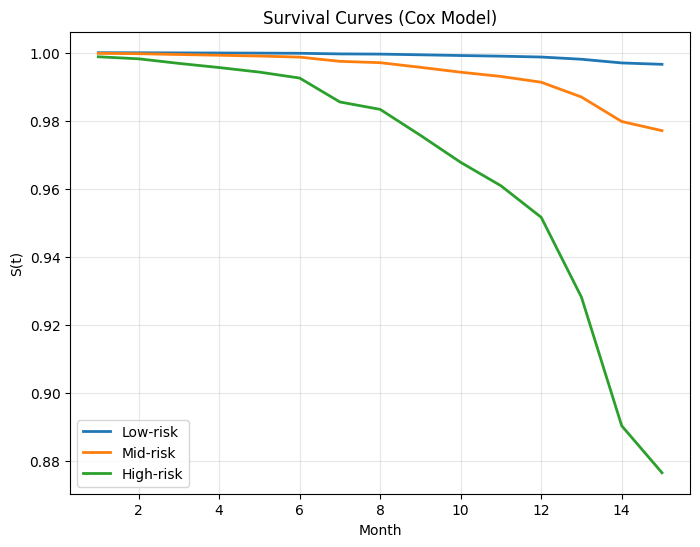

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(t_grid, S_te[idx_low], label="Low-risk", linewidth=2)
plt.plot(t_grid, S_te[idx_mid], label="Mid-risk", linewidth=2)
plt.plot(t_grid, S_te[idx_high], label="High-risk", linewidth=2)

plt.title("Survival Curves (Cox Model)")
plt.xlabel("Month")
plt.ylabel("S(t)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


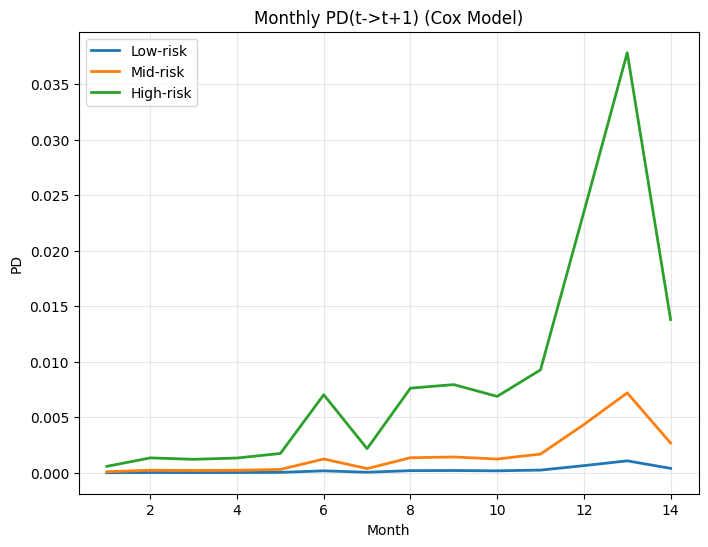

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(t_grid[:-1], PD_te[idx_low], label="Low-risk", linewidth=2)
plt.plot(t_grid[:-1], PD_te[idx_mid], label="Mid-risk", linewidth=2)
plt.plot(t_grid[:-1], PD_te[idx_high], label="High-risk", linewidth=2)

plt.title("Monthly PD(t->t+1) (Cox Model)")
plt.xlabel("Month")
plt.ylabel("PD")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# ks和auc对比

In [ ]:
import numpy as np

# time_te, event_te 是你在构造 test tensor 时就有的那两个数组
t_stop = time_te.astype(int)           # 每一行当前所处的 t
event_next = event_te.astype(int)      # 0/1

print("PD_te shape:", PD_te.shape)
print("len(time_te):", len(t_stop))

# 行索引 & 列索引（列索引 = 对应这行的 t_stop - 1）
row_idx = np.arange(len(t_stop))
col_idx = t_stop - 1
col_idx = np.clip(col_idx, 0, PD_te.shape[1] - 1)  # 保险一下

pd_next_cox = PD_te[row_idx, col_idx]

print("pd_next_cox shape:", pd_next_cox.shape)
print("前 10 个 pd_next_cox:", pd_next_cox[:10])
print("违约率（event_next mean）:", event_next.mean())


PD_te shape: (5811, 14)
len(time_te): 5811
pd_next_cox shape: (5811,)
前 10 个 pd_next_cox: [0.00097357 0.00038365 0.00089458 0.00086198 0.00043238 0.00173488
 0.00077751 0.00056688 0.00035037 0.00081558]
违约率（event_next mean）: 0.004130098089829634


In [ ]:
from sklearn.metrics import roc_auc_score

auc_cox = roc_auc_score(event_next, pd_next_cox)
print("Cox next-month AUC =", auc_cox)


Cox next-month AUC = 0.7017452911698634


In [ ]:
from scipy.stats import ks_2samp

bad_scores = pd_next_cox[event_next == 1]
good_scores = pd_next_cox[event_next == 0]

ks_stat = ks_2samp(bad_scores, good_scores).statistic
print("Cox next-month KS =", ks_stat)


Cox next-month KS = 0.4317219630205633


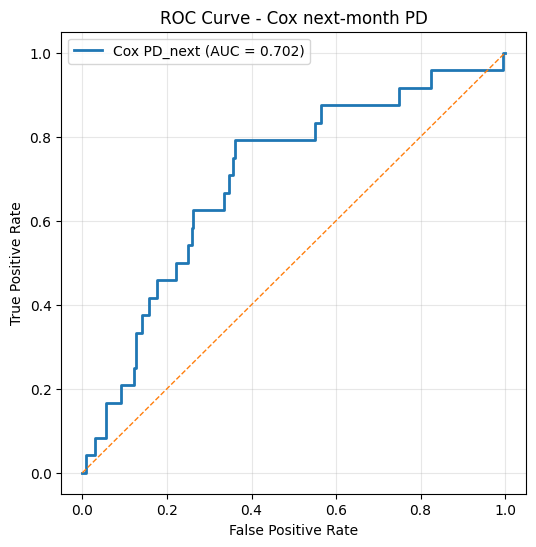

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# ROC for next-month PD
fpr, tpr, thr = roc_curve(event_next, pd_next_cox)
auc_cox = roc_auc_score(event_next, pd_next_cox)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"Cox PD_next (AUC = {auc_cox:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Cox next-month PD")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


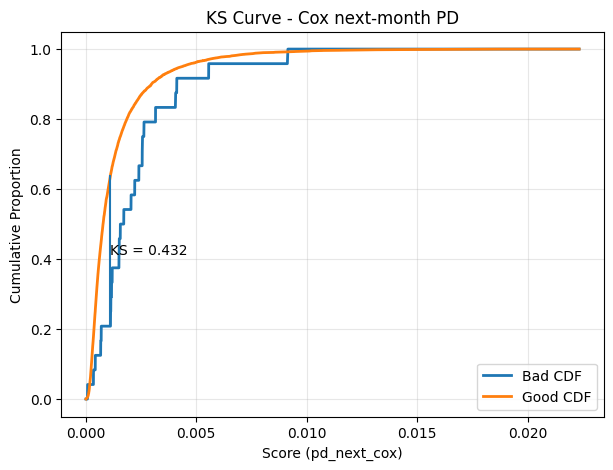

KS (Cox PD_next) = 0.4317219630205633


In [ ]:
# 先按分数从低到高排序
order = np.argsort(pd_next_cox)
score_sorted = pd_next_cox[order]
label_sorted = event_next[order]

# 累计坏客 & 好客占比
cum_bad  = np.cumsum(label_sorted == 1) / (label_sorted == 1).sum()
cum_good = np.cumsum(label_sorted == 0) / (label_sorted == 0).sum()

ks_vals = np.abs(cum_bad - cum_good)
ks_max = ks_vals.max()
ks_idx = ks_vals.argmax()

plt.figure(figsize=(7, 5))
plt.plot(score_sorted, cum_bad,  linewidth=2, label="Bad CDF")
plt.plot(score_sorted, cum_good, linewidth=2, label="Good CDF")
plt.vlines(score_sorted[ks_idx], cum_good[ks_idx], cum_bad[ks_idx])
plt.text(score_sorted[ks_idx], (cum_bad[ks_idx]+cum_good[ks_idx])/2,
         f"KS = {ks_max:.3f}", ha="left", va="center")

plt.xlabel("Score (pd_next_cox)")
plt.ylabel("Cumulative Proportion")
plt.title("KS Curve - Cox next-month PD")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("KS (Cox PD_next) =", ks_max)


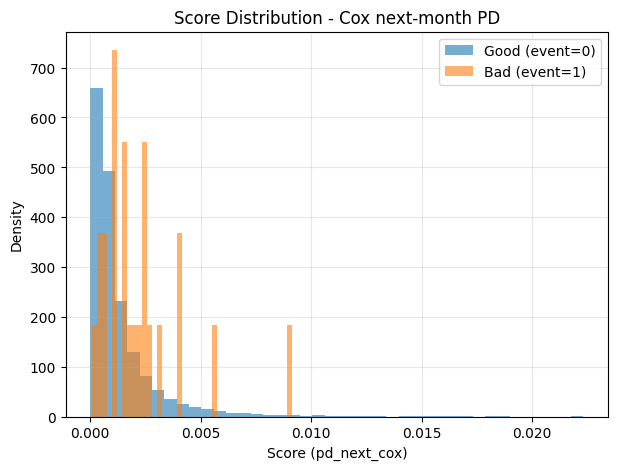

In [ ]:
bad_scores  = pd_next_cox[event_next == 1]
good_scores = pd_next_cox[event_next == 0]

plt.figure(figsize=(7, 5))
plt.hist(good_scores, bins=40, alpha=0.6, density=True, label="Good (event=0)")
plt.hist(bad_scores,  bins=40, alpha=0.6, density=True, label="Bad (event=1)")
plt.xlabel("Score (pd_next_cox)")
plt.ylabel("Density")
plt.title("Score Distribution - Cox next-month PD")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
